In [ ]:
from utils_activations import *


rcpsize = 20
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0


def projection_coefficients(act, syn_centroids, sem_centroids, previous_sem_centroids, eps=1e-8):
    """
    Compute fraction of norm of act explained by:
      - syn_centroids (current layer syntax)
      - sem_centroids (current layer semantics)
      - previous_sem_centroids (all previous layers' semantics, assumed mutually orthogonal)

    Args:
        act: (batch, features) activations
        syn_centroids: (batch, features)
        sem_centroids: (batch, features)
        previous_sem_centroids: list of (batch, features) arrays
        eps: numerical stability

    Returns:
        dict with keys:
          'syn'       : fraction along syntax centroid of current layer
          'sem_curr'  : fraction along semantic centroid of current layer
          'sem_prev'  : fraction along semantic centroids of all previous layers
          'residual'  : remaining fraction
    """

    def squared_norm_fraction(act, centroid):
        # elementwise dot
        dot = jnp.sum(act * centroid, axis=1, keepdims=True)
        centroid_norm_sq = jnp.sum(centroid * centroid, axis=1, keepdims=True) + eps
        proj = (dot / centroid_norm_sq) * centroid
        frac = jnp.sum(proj**2, axis=1) / (jnp.sum(act**2, axis=1) + eps)
        return frac  # shape: (batch,)

    syn_frac = squared_norm_fraction(act, syn_centroids)
    sem_curr_frac = squared_norm_fraction(act, sem_centroids)

    if len(previous_sem_centroids) == 0:
        sem_prev_frac = jnp.zeros_like(syn_frac)
    else:
        sem_prev_frac_list = [squared_norm_fraction(act, p) for p in previous_sem_centroids]
        # because we will enforce orthogonality between all semantic centroids,
        sem_prev_frac = jnp.sum(jnp.stack(sem_prev_frac_list, axis=0), axis=0)

    residual_frac = 1.0 - syn_frac - sem_curr_frac - sem_prev_frac

    fractions = {
        'syn': syn_frac,
        'sem_curr': sem_curr_frac,
        'sem_prev': sem_prev_frac,
        'residual': residual_frac
    }

    return fractions


all_activations_A = None

In [ ]:
n_files = 21
model_name = 'deepseek'
precision = 32
data_var = 'sem'
global_center_flag = 1
min_token_length = 3
avg_tokens = 0

n_tokens = min_token_length 
input_path_A = input_paths['english'][model_name]['matching']['0'][data_var]

if 1:
    all_activations_A = collect_data(input_path_A, 
                                      min_token_length, 
                                      n_files,
                                      model_name,
                                      avg_tokens,
                                      )

layers = list(range(1, depths[model_name] + 1))
layer_vals = reduce_list_half_preserve_extremes(layers)

syn_means = []
sem_curr_means = []
sem_prev_means = []
residual_means = []

# This will store *orthogonalized* semantic centroids from previous layers
previous_sem_centroids_A = []

for enum_layer_id, layer in enumerate(layer_vals):
      
    act_A, syn_centroids_A, sem_centroids_A, global_center_A = preprocessing(
        all_activations_A, 
        layer, 
        space_index='A',
        global_center_flag=global_center_flag,
        avg_tokens=avg_tokens,
        n_tokens=n_tokens,
    )

    # indices for batched_remove_centroid_projections
    idx = jnp.arange(sem_centroids_A.shape[0], dtype=jnp.int32)

    # 1) Remove overlap between syntax and semantic centroids within the current layer
    sem_centroids_A = batched_remove_centroid_projections(
        sem_centroids_A,
        idx,
        syn_centroids_A
    )

    # 2) Make current semantic centroids orthogonal to ALL previous semantic centroids
    for prev_sem in previous_sem_centroids_A:
        sem_centroids_A = batched_remove_centroid_projections(
            sem_centroids_A,
            idx,
            prev_sem
        )

    # 3) Compute fractions of norm
    fractions = projection_coefficients(
        act_A,
        syn_centroids_A,
        sem_centroids_A,
        previous_sem_centroids_A
    )

    syn_means.append(np.mean(np.array(fractions['syn'])))
    sem_curr_means.append(np.mean(np.array(fractions['sem_curr'])))
    sem_prev_means.append(np.mean(np.array(fractions['sem_prev'])))
    residual_means.append(np.mean(np.array(fractions['residual'])))

    # 4) Store the *orthogonalized* semantic centroids from this layer
    previous_sem_centroids_A.append(sem_centroids_A)

# Convert to numpy arrays for easier stacking / plotting
syn_means = np.array(syn_means)
sem_curr_means = np.array(sem_curr_means)
sem_prev_means = np.array(sem_prev_means)
residual_means = np.array(residual_means)

rel_depths = (np.array(layer_vals)) / (depths[model_name])


deepseek dtype: torch.bfloat16


Collect File: 100%|██████████| 21/21 [00:08<00:00,  2.33it/s]


all_hidden_states["layer_0"].shape=torch.Size([2018, 3, 7168])
importing took 0.19244533777236938 m


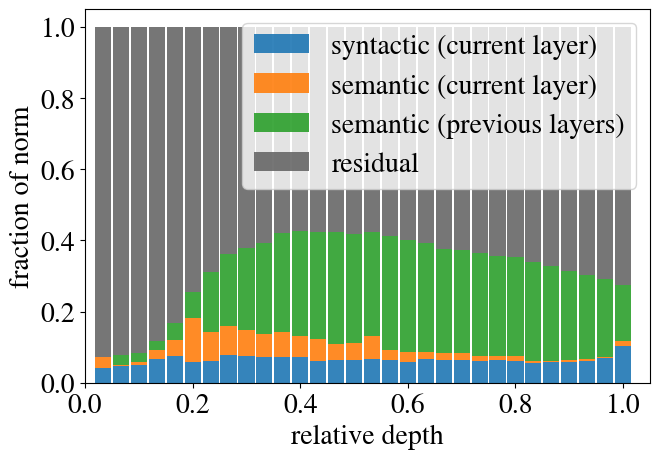

In [6]:
# Plot
fig, ax = plt.subplots(figsize=(7, 5))

bar_width = 0.03  # adjust for [0, 1] x-axis
n_layers = len(rel_depths)
x = np.linspace(1/n_layers, 1, n_layers)
# if you prefer: x = rel_depths

# stacked bars
ax.bar(
    x, syn_means,
    width=bar_width,
    color="#1f77b4",
    label="syntactic (current layer)",
    alpha=0.9,
)

ax.bar(
    x, sem_curr_means,
    width=bar_width,
    bottom=syn_means,
    color="#ff7f0e",
    label="semantic (current layer)",
    alpha=0.9,
)

ax.bar(
    x, sem_prev_means,
    width=bar_width,
    bottom=syn_means + sem_curr_means,
    color="#2ca02c",
    label="semantic (previous layers)",
    alpha=0.9,
)

ax.bar(
    x, residual_means,
    width=bar_width,
    bottom=syn_means + sem_curr_means + sem_prev_means,
    color="#676767",
    label="residual",
    alpha=0.9,
)

ax.set_xticks(np.linspace(0, 1, 6))
ax.set_xticklabels([f"{t:.1f}" for t in np.linspace(0, 1, 6)])
ax.set_xlabel("relative depth", fontsize=rcpsize)
ax.set_ylabel("fraction of norm", fontsize=rcpsize)

ax.legend()
ax.set_xlim(0, 1.05)
plt.tight_layout()

figs_folder = 'results/figs/norms/'
os.makedirs(figs_folder, exist_ok=True)
fig.savefig(os.path.join(figs_folder, 'syn_sem_norms_split_sem.pdf'))
plt.show()


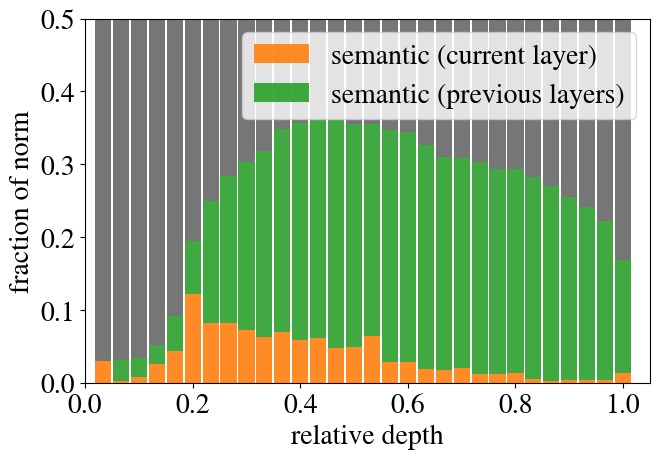

In [25]:
### No syntax version 

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

bar_width = 0.03  # adjust for [0, 1] x-axis
n_layers = len(rel_depths)
x = np.linspace(1/n_layers, 1, n_layers)
# if you prefer: x = rel_depths

ax.bar(
    x, sem_curr_means,
    width=bar_width,
    bottom=0,
    color="#ff7f0e",
    label="semantic (current layer)",
    alpha=0.9,
)

ax.bar(
    x, sem_prev_means,
    width=bar_width,
    bottom=sem_curr_means,
    color="#2ca02c",
    label="semantic (previous layers)",
    alpha=0.9,
)

ax.bar(
    x, residual_means + syn_means,
    width=bar_width,
    bottom=sem_curr_means + sem_prev_means,
    color="#676767",
    # label="residual",
    alpha=0.9,
)

ax.set_xticks(np.linspace(0, 1, 6))
ax.set_xticklabels([f"{t:.1f}" for t in np.linspace(0, 1, 6)])
ax.set_xlabel("relative depth", fontsize=rcpsize)
ax.set_ylabel("fraction of norm", fontsize=rcpsize)

ax.legend(loc='center')
ax.legend()
ax.set_xlim(0, 1.05)
ax.set_ylim(0,.5)
plt.tight_layout()

figs_folder = 'results/figs/norms/'
os.makedirs(figs_folder, exist_ok=True)
fig.savefig(os.path.join(figs_folder, 'sem_norms_cumulative.pdf'))
plt.show()

In [10]:
def projection_coefficients(act,
                            syn_centroids,
                            sem_centroids,
                            previous_sem_centroids,
                            previous_syn_centroids,
                            eps=1e-8):
    """
    Compute fraction of norm of `act` explained by:
      - syn_curr: syntax centroid of current layer
      - syn_prev: syntax centroids of previous layers
      - sem_curr: semantic centroid of current layer
      - sem_prev: semantic centroids of previous layers
      - residual: rest

    All centroids (within each family) are assumed orthogonal due to preprocessing.
    """

    def squared_norm_fraction(act, centroid):
        dot = jnp.sum(act * centroid, axis=1, keepdims=True)
        centroid_norm_sq = jnp.sum(centroid * centroid, axis=1, keepdims=True) + eps
        proj = (dot / centroid_norm_sq) * centroid
        frac = jnp.sum(proj**2, axis=1) / (jnp.sum(act**2, axis=1) + eps)
        return frac  # (batch,)

    syn_curr_frac = squared_norm_fraction(act, syn_centroids)
    sem_curr_frac = squared_norm_fraction(act, sem_centroids)

    if len(previous_sem_centroids) == 0:
        sem_prev_frac = jnp.zeros_like(syn_curr_frac)
    else:
        sem_prev_list = [squared_norm_fraction(act, p) for p in previous_sem_centroids]
        sem_prev_frac = jnp.sum(jnp.stack(sem_prev_list, axis=0), axis=0)

    if len(previous_syn_centroids) == 0:
        syn_prev_frac = jnp.zeros_like(syn_curr_frac)
    else:
        syn_prev_list = [squared_norm_fraction(act, p) for p in previous_syn_centroids]
        syn_prev_frac = jnp.sum(jnp.stack(syn_prev_list, axis=0), axis=0)

    residual_frac = 1.0 - syn_curr_frac - syn_prev_frac - sem_curr_frac - sem_prev_frac

    return {
        "syn_curr": syn_curr_frac,
        "syn_prev": syn_prev_frac,
        "sem_curr": sem_curr_frac,
        "sem_prev": sem_prev_frac,
        "residual": residual_frac,
    }

In [11]:
layers = list(range(1, depths[model_name] + 1))
layer_vals = reduce_list_half_preserve_extremes(layers)

syn_curr_means = []
syn_prev_means = []
sem_curr_means = []
sem_prev_means = []
residual_means = []

previous_sem_centroids_A = []
previous_syn_centroids_A = []

for enum_layer_id, layer in enumerate(layer_vals):

    act_A, syn_centroids_A, sem_centroids_A, global_center_A = preprocessing(
        all_activations_A, 
        layer, 
        space_index='A',
        global_center_flag=global_center_flag,
        avg_tokens=avg_tokens,
        n_tokens=n_tokens,
    )

    idx = jnp.arange(sem_centroids_A.shape[0], dtype=jnp.int32)

    # 1) Remove syn-sem overlap within current layer
    sem_centroids_A = batched_remove_centroid_projections(
        sem_centroids_A,
        idx,
        syn_centroids_A,
    )

    # 2) Make current semantics orthogonal to all previous semantics
    for prev_sem in previous_sem_centroids_A:
        sem_centroids_A = batched_remove_centroid_projections(
            sem_centroids_A,
            idx,
            prev_sem,
        )

    # 3) Make current syntax orthogonal to all previous syntax
    for prev_syn in previous_syn_centroids_A:
        syn_centroids_A = batched_remove_centroid_projections(
            syn_centroids_A,
            idx,
            prev_syn,
        )

    # 4) Fractions
    fractions = projection_coefficients(
        act_A,
        syn_centroids_A,
        sem_centroids_A,
        previous_sem_centroids_A,
        previous_syn_centroids_A,
    )

    syn_curr_means.append(np.mean(np.array(fractions['syn_curr'])))
    syn_prev_means.append(np.mean(np.array(fractions['syn_prev'])))
    sem_curr_means.append(np.mean(np.array(fractions['sem_curr'])))
    sem_prev_means.append(np.mean(np.array(fractions['sem_prev'])))
    residual_means.append(np.mean(np.array(fractions['residual'])))

    # 5) Save *orthogonalized* centroids for next layers
    previous_sem_centroids_A.append(sem_centroids_A)
    previous_syn_centroids_A.append(syn_centroids_A)

# to numpy
syn_curr_means = np.array(syn_curr_means)
syn_prev_means = np.array(syn_prev_means)
sem_curr_means = np.array(sem_curr_means)
sem_prev_means = np.array(sem_prev_means)
residual_means = np.array(residual_means)

rel_depths = (np.array(layer_vals)) / (depths[model_name])


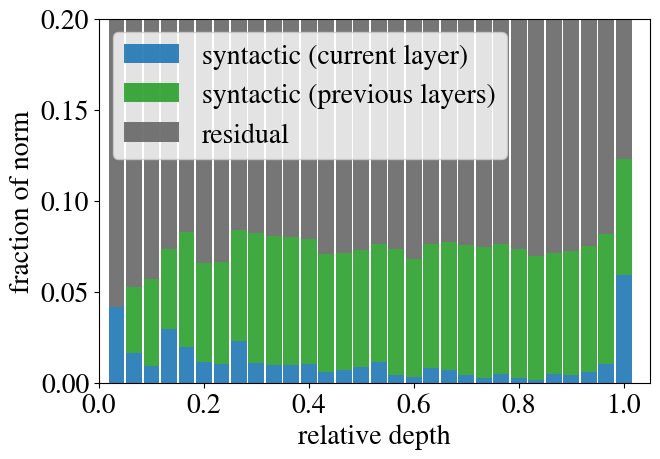

In [18]:
# Syntax-focused plot
fig, ax = plt.subplots(figsize=(7, 5))

bar_width = 0.03
n_layers = len(rel_depths)
x = np.linspace(1/n_layers, 1, n_layers)   # or x = rel_depths

sem_total_means = sem_curr_means + sem_prev_means

ax.bar(
    x, syn_curr_means,
    width=bar_width,
    color="#1f77b4",
    label="syntactic (current layer)",
    alpha=0.9,
)

ax.bar(
    x, syn_prev_means,
    width=bar_width,
    bottom=syn_curr_means,
    color="#2ca02c",
    label="syntactic (previous layers)",
    alpha=0.9,
)

ax.bar(
    x, residual_means + sem_total_means,
    width=bar_width,
    bottom=syn_curr_means + syn_prev_means,
    color="#676767",
    label="residual",
    alpha=0.9,
)

ax.set_xticks(np.linspace(0, 1, 6))
ax.set_xticklabels([f"{t:.1f}" for t in np.linspace(0, 1, 6)])
ax.set_xlabel("relative depth", fontsize=rcpsize)
ax.set_ylabel("fraction of norm", fontsize=rcpsize)

ax.legend(loc='upper left')
ax.set_xlim(0, 1.05)
ax.set_ylim(0,.2)
plt.tight_layout()

figs_folder = 'results/figs/norms/'
os.makedirs(figs_folder, exist_ok=True)
fig.savefig(os.path.join(figs_folder, 'syntax_cumulative_norms.pdf'))
plt.show()
